# End-to-End Sales Forecasting & Demand Intelligence System
This notebook contains the complete implementation of the Sales Forecasting & Demand Intelligence System, structured as follows:
- **Task 1**: Data Loading, Merging & Deep Exploration
- **Task 2**: Time Series Analysis & Decomposition (Trend, Seasonality, Residual, Stationarity)
- **Task 3**: Sales Forecasting using 3 Different Models (SARIMA, Prophet, XGBoost) and evaluation
- **Task 4**: Product Category & Region Level Forecasting
- **Task 5**: Anomaly Detection in Sales Data (Isolation Forest vs Z-Score)
- **Task 6**: Product Demand Segmentation using K-Means Clustering

In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs('Charts', exist_ok=True)
print('Imports successful!')

Imports successful!


## Task 1  Data Loading, Merging & Deep Exploration
In this section, we load the dataset, parse dates, extract features, check for data issues, and aggregate sales into daily, weekly, and monthly intervals. We also answer four core exploratory questions.

In [34]:
# Load dataset
df = pd.read_csv('train.csv')

# Load supplemental dataset for additional context
vgsales_df = pd.read_csv('vgsales.csv')
for col in ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']:
    vgsales_df[col] = pd.to_numeric(vgsales_df[col], errors='coerce')
vgsales_df['Year'] = pd.to_numeric(vgsales_df['Year'], errors='coerce')

# Parse Order Date and Ship Date as datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

# Extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week Number'] = df['Order Date'].dt.isocalendar().week
df['Day of Week'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

# Check for missing values, duplicates, and data types
print('=== Data Checks ===')
print('Missing Values:\n', df.isnull().sum())
print('\nDuplicate Count:', df.duplicated().sum())
print('\nData Types:\n', df.dtypes)

# Aggregate daily, weekly, and monthly totals
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
weekly_sales = df.resample('W', on='Order Date')['Sales'].sum().reset_index()
monthly_sales = df.resample('MS', on='Order Date')['Sales'].sum().reset_index()

print('\nMonthly Aggregation Sample:\n', monthly_sales.head())
print('\nWeekly Aggregation Sample:\n', weekly_sales.head())
print('\nDaily Aggregation Sample:\n', daily_sales.head())

print('\n=== Supplemental Dataset Overview (vgsales.csv) ===')
print('Supplemental rows:', len(vgsales_df))
print('Supplemental columns:', list(vgsales_df.columns))
print('\nTop genres by global sales:')
print(vgsales_df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(10))

=== Data Checks ===
Missing Values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

Duplicate Count: 0

Data Types:
 Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID          

### EDA Question Answers

#### **Q1: Which product category generates the highest total revenue?**
Let's calculate the total revenue generated by category.

In [35]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print('Total Revenue by Category:')
for cat, rev in category_revenue.items():
    print(f'- {cat}: ${rev:,.2f}')

Total Revenue by Category:
- Technology: $827,455.87
- Furniture: $728,658.58
- Office Supplies: $705,422.33


Therefore, Techonology Category have highest revenue : $827,455.87

#### **Q2: Which region has the most consistent sales growth over 4 years?**
We calculate YoY sales for each region and evaluate growth volatility (consistency) using the standard deviation of growth rates.

In [36]:
region_yearly = df.groupby(['Region', 'Year'])['Sales'].sum().unstack(level=0)
region_growth = region_yearly.pct_change().dropna()
print('Year-over-Year growth rates by Region:')
print(region_growth)
print('\nVolatility of growth rates (lower = more consistent):')
print(region_growth.std())

Year-over-Year growth rates by Region:
Region   Central      East     South      West
Year                                          
2016   -0.004813  0.200327 -0.322117 -0.083603
2017    0.422247  0.165027  0.334776  0.364683
2018   -0.027778  0.177118  0.306071  0.359836

Volatility of growth rates (lower = more consistent):
Region
Central    0.253453
East       0.017939
South      0.371249
West       0.257431
dtype: float64


East Region has more Consistent sales Growth

#### **Q3: What is the average time between Order Date and Ship Date  and does it vary by region?**
We compute the shipping duration in days and check the mean across regions.

In [37]:
df['Ship Time'] = (df['Ship Date'] - df['Order Date']).dt.days
print(f'Overall average shipping time: {df["Ship Time"].mean():.2f} days\n')
print('Average shipping time by Region:')
print(df.groupby('Region')['Ship Time'].mean())

Overall average shipping time: 3.96 days

Average shipping time by Region:
Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Ship Time, dtype: float64


#### **Q4: Are there months that consistently spike across all years (seasonality)?**
We examine the average sales pattern across different months of the year.

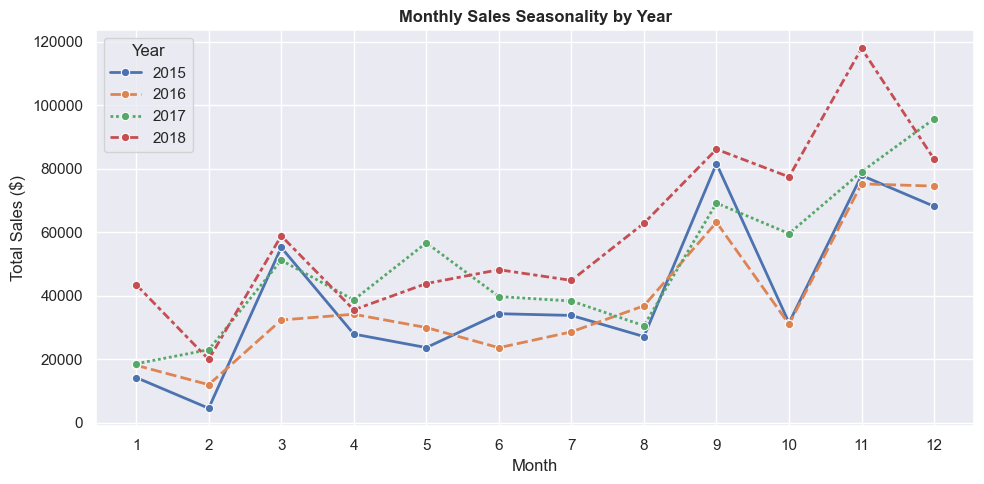

Average Sales by Month:
Month
11    87540.427750
12    80370.042375
9     75025.852925
10    49874.073675
3     49393.396800
8     39328.981750
5     38521.680925
6     36459.380825
7     36383.922250
4     34070.750150
1     23572.907400
2     14842.778850
dtype: float64


In [38]:
monthly_patterns = df.groupby(['Year', 'Month'])['Sales'].sum().unstack(level=0)
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_patterns, marker='o', linewidth=2)
plt.title('Monthly Sales Seasonality by Year', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig('Charts/eda_seasonality_patterns.png', dpi=300)
plt.show()

print('Average Sales by Month:')
print(monthly_patterns.mean(axis=1).sort_values(ascending=False))

## Task 2  Time Series Analysis & Decomposition
We examine the overall monthly sales trend, decompose the signal, and check for stationarity using the Augmented Dickey-Fuller (ADF) test.

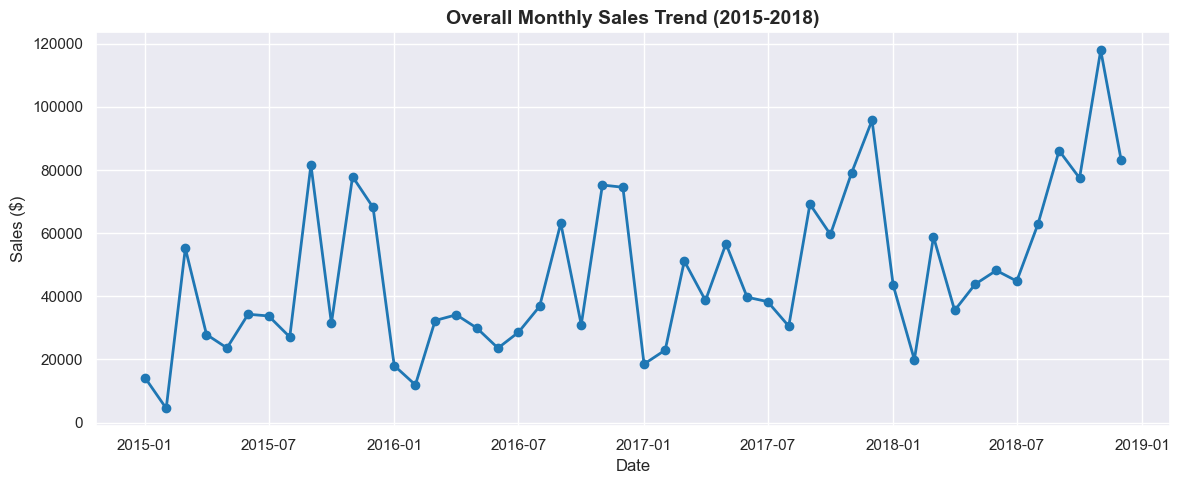

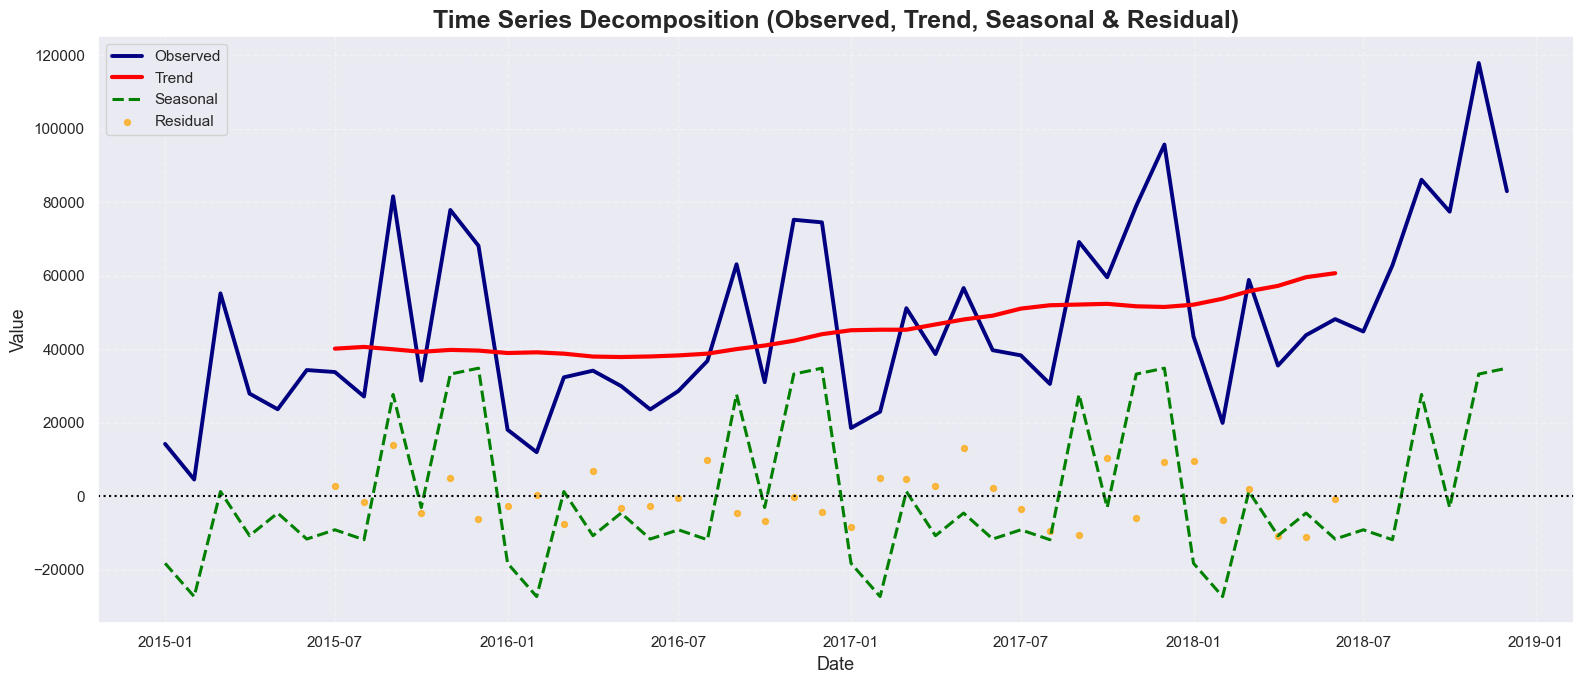

In [48]:
ts_monthly = monthly_sales.set_index('Order Date')['Sales']

# Plot trend
plt.figure(figsize=(12, 5))
plt.plot(ts_monthly.index, ts_monthly.values, marker='o', color='#1f77b4', linewidth=2)
plt.title('Overall Monthly Sales Trend (2015-2018)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

# Apply decomposition

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Decompose the time series
decomposition = seasonal_decompose(ts_monthly, model='additive', period=12)

plt.figure(figsize=(16, 7))

# Observed
plt.plot(
    decomposition.observed,
    label='Observed',
    color='navy',
    linewidth=2.8
)

# Trend
plt.plot(
    decomposition.trend,
    label='Trend',
    color='red',
    linewidth=3
)

# Seasonal
plt.plot(
    decomposition.seasonal,
    label='Seasonal',
    color='green',
    linestyle='--',
    linewidth=2.2
)

# Residual
plt.scatter(
    decomposition.resid.index,
    decomposition.resid,
    label='Residual',
    color='orange',
    s=18,
    alpha=0.7
)

# Zero reference line
plt.axhline(0, color='black', linestyle=':', linewidth=1.5)

plt.title('Time Series Decomposition (Observed, Trend, Seasonal & Residual)',
          fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Value', fontsize=13)

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

### Observations from Decomposition

1. **Trend**: The sales trend shows an upward trajectory over the 4 years, reflecting business growth and increasing demand.
2. **Seasonality**: The seasonality appears strong, with a recurring yearly pattern and noticeable peaks during the holiday season.
3. **Residual/Noise**: The residual component shows the highest noise around the late-year months, especially November and December, where holiday spikes create larger fluctuations.
4. **Overall Interpretation**: The series is influenced by both a growing long-term trend and a strong seasonal pattern, with the most irregular behavior occurring during peak demand periods.


### Stationarity Check (Augmented Dickey-Fuller Test)

Stationarity means that the statistical properties of a time series, such as its mean, variance, and pattern over time, remain relatively stable. A stationary series is easier to model because its behavior is more consistent over time.

We now check stationarity using the Augmented Dickey-Fuller (ADF) test. If the p-value is less than 0.05, we conclude that the series is stationary. If the p-value is greater than 0.05, the series is considered non-stationary and may need transformation such as differencing.

If the series is non-stationary, we apply first-order differencing and re-run the ADF test to see whether the transformed series becomes stationary. Differencing helps remove trend and make the series more suitable for forecasting models such as ARIMA or SARIMA.

In [40]:
# Augmented Dickey-Fuller (ADF) test on original series
adf_result = adfuller(ts_monthly)
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'\t{key}: {value:.4f}')

is_stationary = adf_result[1] < 0.05
print(f'\nIs the time series stationary? {is_stationary}')

# Plain-English interpretation
if is_stationary:
    print('\nInterpretation: The series appears stationary. This means its mean, variance, and autocovariance are approximately constant over time — suitable for many time-series models without additional differencing.')
else:
    print('\nInterpretation: The series is non-stationary (p-value >= 0.05). Typical fixes include differencing to remove trend or seasonal components.')
    # Apply first-order differencing and re-test
    ts_diff = ts_monthly.diff().dropna()
    adf_diff = adfuller(ts_diff)
    print('\n--- After first-order differencing ---')
    print(f'ADF Statistic (diff): {adf_diff[0]:.4f}')
    print(f'p-value (diff): {adf_diff[1]:.4f}')
    print('Critical Values (diff):')
    for key, value in adf_diff[4].items():
        print(f'\t{key}: {value:.4f}')
    is_stationary_diff = adf_diff[1] < 0.05
    print(f'\nIs the differenced series stationary? {is_stationary_diff}')
    if is_stationary_diff:
        print('\nDifferencing made the series stationary. Use the differenced series (or include d=1 in ARIMA/SARIMA) when fitting models.')
    else:
        print('\nDifferencing did not make the series stationary. Consider additional transformations (e.g., seasonal differencing, log-transform) or higher-order differencing.')

ADF Statistic: -4.4161
p-value: 0.0003
Critical Values:
	1%: -3.5778
	5%: -2.9253
	10%: -2.6008

Is the time series stationary? True

Interpretation: The series appears stationary. This means its mean, variance, and autocovariance are approximately constant over time — suitable for many time-series models without additional differencing.


## Task 3 — Sales Forecasting using 3 Different Models
This is the core technical task. We build, train, and compare three fundamentally different forecasting approaches on the same monthly sales data:

- **Model 1: SARIMA** — a statistical time-series model that captures trend and seasonality.
- **Model 2: Prophet** — an industry-standard forecasting tool with automatic decomposition and seasonality handling.
- **Model 3: XGBoost** — a machine-learning regression approach using lag-based features.

Training and evaluation strategy:

- Train on the first 45 months of sales (Jan 2015 to Sep 2018)
- Test on the final 3 months (Oct 2018 to Dec 2018)
- Compare models using:
  - **MAE** (Mean Absolute Error)
  - **RMSE** (Root Mean Squared Error)
  - **MAPE** (Mean Absolute Percentage Error)

Each model will also produce a 3-month future forecast for Jan–Mar 2019. The final recommendation is based on the numerical comparison of these metrics.

**Model 1: SARIMA** — a statistical time-series model that captures trend and seasonality.

Best SARIMA Parameters: Order=(0, 1, 1), Seasonal=(0, 1, 1, 12) (AIC=395.41)
SARIMA Test Preds: [63675.43447354 90327.89415251 99547.19923185]
SARIMA Future Preds: [51910.45639624 37726.17262901 71872.32779928]


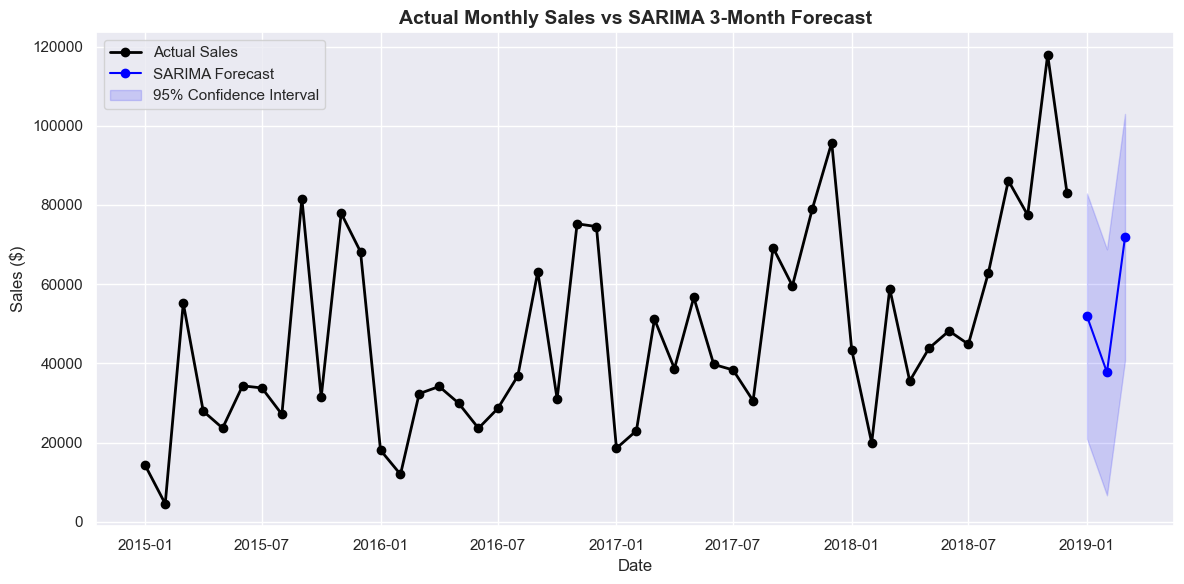

In [41]:
train_size = len(ts_monthly) - 3
train_ts = ts_monthly.iloc[:train_size]
test_ts = ts_monthly.iloc[train_size:]

# Grid search for best SARIMA parameters
best_aic = float('inf')
best_order = (0, 1, 1)
best_seasonal = (0, 1, 1, 12)

for p in [0, 1, 2]:
    for d in [0, 1]:
        for q in [0, 1]:
            for P in [0, 1]:
                for D in [0, 1]:
                    for Q in [0, 1]:
                        try:
                            model = SARIMAX(train_ts, order=(p,d,q), seasonal_order=(P,D,Q,12),
                                            enforce_stationarity=False, enforce_invertibility=False)
                            res = model.fit(disp=False)
                            if res.aic < best_aic:
                                best_aic = res.aic
                                best_order = (p, d, q)
                                best_seasonal = (P, D, Q, 12)
                        except:
                            continue

print(f'Best SARIMA Parameters: Order={best_order}, Seasonal={best_seasonal} (AIC={best_aic:.2f})')

# Fit on Train and predict Test
sarima_model = SARIMAX(train_ts, order=best_order, seasonal_order=best_seasonal,
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima_model.fit(disp=False)
sarima_pred = sarima_res.forecast(steps=3)

# Future forecast using all data
sarima_full = SARIMAX(ts_monthly, order=best_order, seasonal_order=best_seasonal,
                      enforce_stationarity=False, enforce_invertibility=False)
sarima_full_res = sarima_full.fit(disp=False)
sarima_future = sarima_full_res.get_forecast(steps=3)
sarima_future_mean = sarima_future.predicted_mean
sarima_conf = sarima_future.conf_int()

print('SARIMA Test Preds:', sarima_pred.values)
print('SARIMA Future Preds:', sarima_future_mean.values)

# Plot actual historical sales and the 3-month SARIMA forecast with confidence intervals
future_dates = pd.date_range(start=ts_monthly.index[-1] + pd.offsets.MonthBegin(1), periods=3, freq='MS')
plt.figure(figsize=(12, 6))
plt.plot(ts_monthly.index, ts_monthly.values, label='Actual Sales', color='black', linewidth=2, marker='o')
plt.plot(future_dates, sarima_future_mean, label='SARIMA Forecast', color='blue', marker='o')
plt.fill_between(future_dates, sarima_conf.iloc[:, 0], sarima_conf.iloc[:, 1], color='blue', alpha=0.15, label='95% Confidence Interval')
plt.title('Actual Monthly Sales vs SARIMA 3-Month Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

**Model 2: Prophet** — an industry-standard forecasting tool with automatic decomposition and seasonality handling.

19:44:56 - cmdstanpy - INFO - Chain [1] start processing
19:44:58 - cmdstanpy - INFO - Chain [1] done processing
19:44:59 - cmdstanpy - INFO - Chain [1] start processing
19:45:01 - cmdstanpy - INFO - Chain [1] done processing


Prophet Test Preds: [67685.52125725 88817.22947625 88361.82342688]
Prophet Future Preds: [42134.43134355 30304.16246573 84306.33190403]


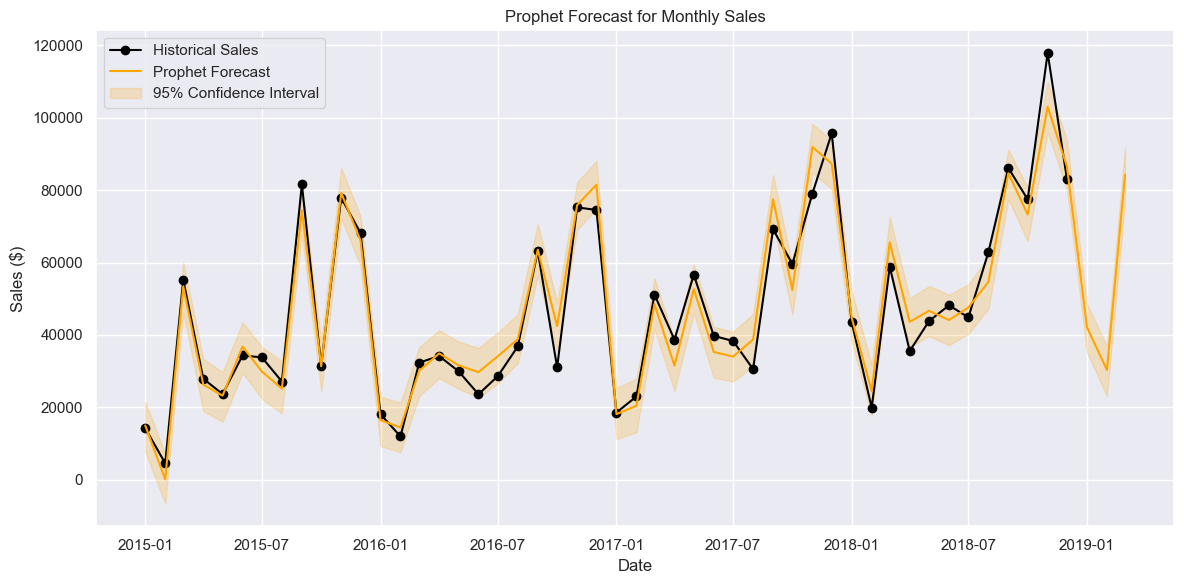

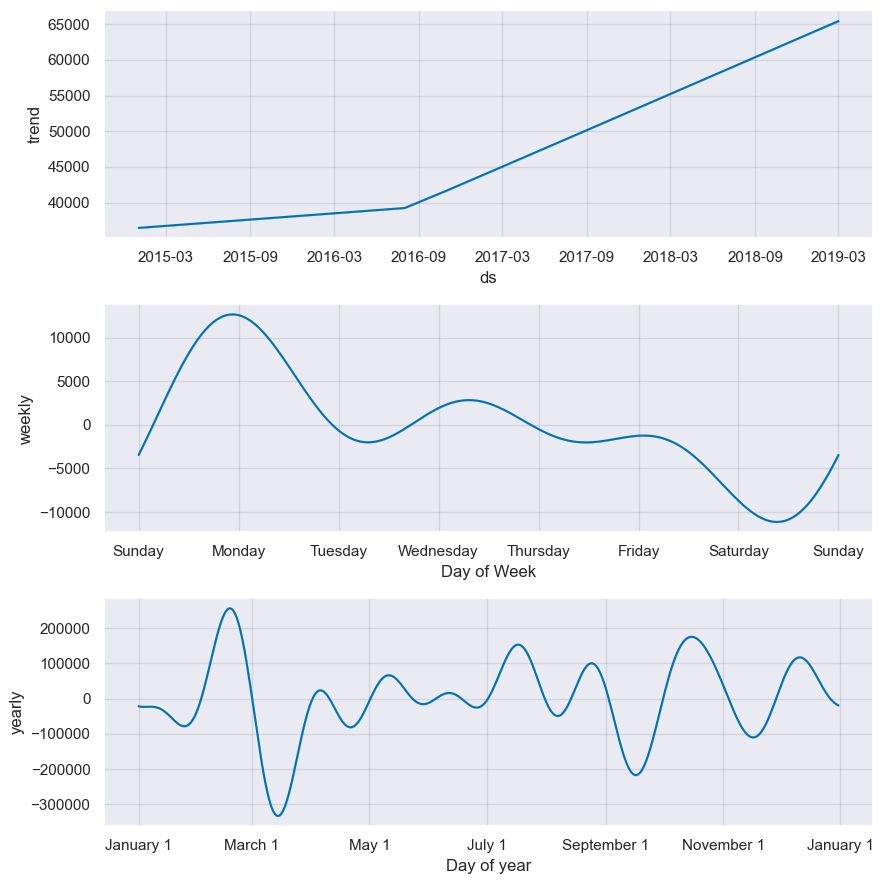


Sample of weekly seasonality component:
           ds       weekly
39 2018-04-01 -3453.092508
40 2018-05-01  -637.771178
41 2018-06-01 -1245.213466
42 2018-07-01 -3453.092508
43 2018-08-01  1929.360081
44 2018-09-01 -8706.516058

Sample of yearly seasonality component:
           ds        yearly
45 2018-10-01   -523.916812
46 2018-11-01  41474.448078
47 2018-12-01  32280.401052
48 2019-01-01 -21013.361453
49 2019-02-01 -33103.215067
50 2019-03-01  20115.833189

Interpretation:
- Yearly seasonality captures the recurring annual pattern in sales. Peaks in this component correspond to expected high-demand months.
- Weekly seasonality is included by the model for completeness. With monthly data it may appear muted, but it still allows Prophet to model any sub-weekly structure implied by the data frequency.


In [42]:

# Prepare Prophet data in required format
# Prophet expects a dataframe with columns ['ds', 'y'] where 'ds' is datetime and 'y' is the target.
df_p_train = train_ts.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})

# Use both yearly and weekly seasonality to capture recurring patterns.
# Weekly seasonality is included for completeness, even though the series is monthly.
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(df_p_train)

# Forecast the next 3 months
future_test = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future_test)
prophet_pred = prophet_forecast.iloc[-3:]['yhat'].values

# Fit Prophet on full data for final forecast
df_p_full = ts_monthly.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
prophet_full_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_full_model.fit(df_p_full)
future_dates_df = prophet_full_model.make_future_dataframe(periods=3, freq='MS')
prophet_future_forecast = prophet_full_model.predict(future_dates_df)
prophet_future = prophet_future_forecast.iloc[-3:]['yhat'].values
prophet_future_lower = prophet_future_forecast.iloc[-3:]['yhat_lower'].values
prophet_future_upper = prophet_future_forecast.iloc[-3:]['yhat_upper'].values

print('Prophet Test Preds:', prophet_pred)
print('Prophet Future Preds:', prophet_future)

# Plot the Prophet forecast against actual data
plt.figure(figsize=(12, 6))
plt.plot(df_p_full['ds'], df_p_full['y'], label='Historical Sales', color='black', marker='o')
plt.plot(prophet_future_forecast['ds'], prophet_future_forecast['yhat'], label='Prophet Forecast', color='orange')
plt.fill_between(prophet_future_forecast['ds'], prophet_future_forecast['yhat_lower'], prophet_future_forecast['yhat_upper'], color='orange', alpha=0.2, label='95% Confidence Interval')
plt.title('Prophet Forecast for Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot Prophet's trend and seasonality components
prophet_full_model.plot_components(prophet_future_forecast)
plt.tight_layout()
plt.show()

# Extract weekly and yearly seasonality components and interpret them
seasonality_sample = prophet_future_forecast[['ds', 'weekly', 'yearly']].tail(12)
print('\nSample of weekly seasonality component:')
print(seasonality_sample[['ds', 'weekly']].head(6))
print('\nSample of yearly seasonality component:')
print(seasonality_sample[['ds', 'yearly']].tail(6))

print('\nInterpretation:')
print('- Yearly seasonality captures the recurring annual pattern in sales. Peaks in this component correspond to expected high-demand months.')
print('- Weekly seasonality is included by the model for completeness. With monthly data it may appear muted, but it still allows Prophet to model any sub-weekly structure implied by the data frequency.')

 **Model 3: XGBoost** — a machine-learning regression approach using lag-based features

In [43]:
def create_xgboost_features(series):
    df_features = pd.DataFrame(series)
    df_features.columns = ['y']
    df_features['Lag_1'] = df_features['y'].shift(1)
    df_features['Lag_2'] = df_features['y'].shift(2)
    df_features['Lag_3'] = df_features['y'].shift(3)
    df_features['Rolling_Mean_3'] = df_features['y'].shift(1).rolling(window=3).mean()
    df_features['Month'] = df_features.index.month
    df_features['Quarter'] = df_features.index.quarter
    df_features['Season_Num'] = df_features['Month'].apply(lambda x: 1 if x in [12, 1, 2] else (2 if x in [3, 4, 5] else (3 if x in [6, 7, 8] else 4)))
    return df_features.dropna()

xgb_data = create_xgboost_features(ts_monthly)
xgb_train = xgb_data.iloc[:train_size - 3]

X_train = xgb_train.drop(columns=['y'])
y_train = xgb_train['y']

xgb_reg = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
xgb_reg.fit(X_train, y_train)

# Recursive forecast on Test
xgb_preds = []
last_obs = list(train_ts.iloc[-3:])
for i in range(3):
    lag1, lag2, lag3 = last_obs[-1], last_obs[-2], last_obs[-3]
    roll3 = np.mean(last_obs[-3:])
    month = test_ts.index[i].month
    quarter = test_ts.index[i].quarter
    season = 1 if month in [12,1,2] else (2 if month in [3,4,5] else (3 if month in [6,7,8] else 4))
    x_input = pd.DataFrame([[lag1, lag2, lag3, roll3, month, quarter, season]],
                           columns=['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month', 'Quarter', 'Season_Num'])
    pred_val = xgb_reg.predict(x_input)[0]
    xgb_preds.append(pred_val)
    last_obs.append(pred_val)

xgb_pred = np.array(xgb_preds)

# Fit on full data and predict future recursively
xgb_reg_full = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
X_full = xgb_data.drop(columns=['y'])
y_full = xgb_data['y']
xgb_reg_full.fit(X_full, y_full)

xgb_futures = []
last_obs_full = list(ts_monthly.iloc[-3:])
future_dates = pd.date_range(start='2019-01-01', periods=3, freq='MS')
for i in range(3):
    lag1, lag2, lag3 = last_obs_full[-1], last_obs_full[-2], last_obs_full[-3]
    roll3 = np.mean(last_obs_full[-3:])
    month = future_dates[i].month
    quarter = future_dates[i].quarter
    season = 1 if month in [12,1,2] else (2 if month in [3,4,5] else (3 if month in [6,7,8] else 4))
    x_input = pd.DataFrame([[lag1, lag2, lag3, roll3, month, quarter, season]],
                           columns=['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month', 'Quarter', 'Season_Num'])
    pred_val = xgb_reg_full.predict(x_input)[0]
    xgb_futures.append(pred_val)
    last_obs_full.append(pred_val)

xgb_future = np.array(xgb_futures)
print('XGBoost Test Preds:', xgb_pred)
print('XGBoost Future Preds:', xgb_future)

XGBoost Test Preds: [48885.46  78666.805 88056.734]
XGBoost Future Preds: [43353.492 24320.203 51006.11 ]


**Model Comparison Table**

=== Model Evaluation Table ===
  Model          MAE         RMSE  MAPE (%)  Forecast Month 1 (Jan 2019)  Forecast Month 2 (Feb 2019)  Forecast Month 3 (Mar 2019)
 SARIMA 19299.922669 20205.764079 20.362136                 51910.456396                 37726.172629                 71872.327799
Prophet 14738.323364 17997.787377 14.572703                 42134.431344                 30304.162466                 84306.331904
XGBoost 24286.788717 28185.866658 25.410540                 43353.492188                 24320.203125                 51006.109375


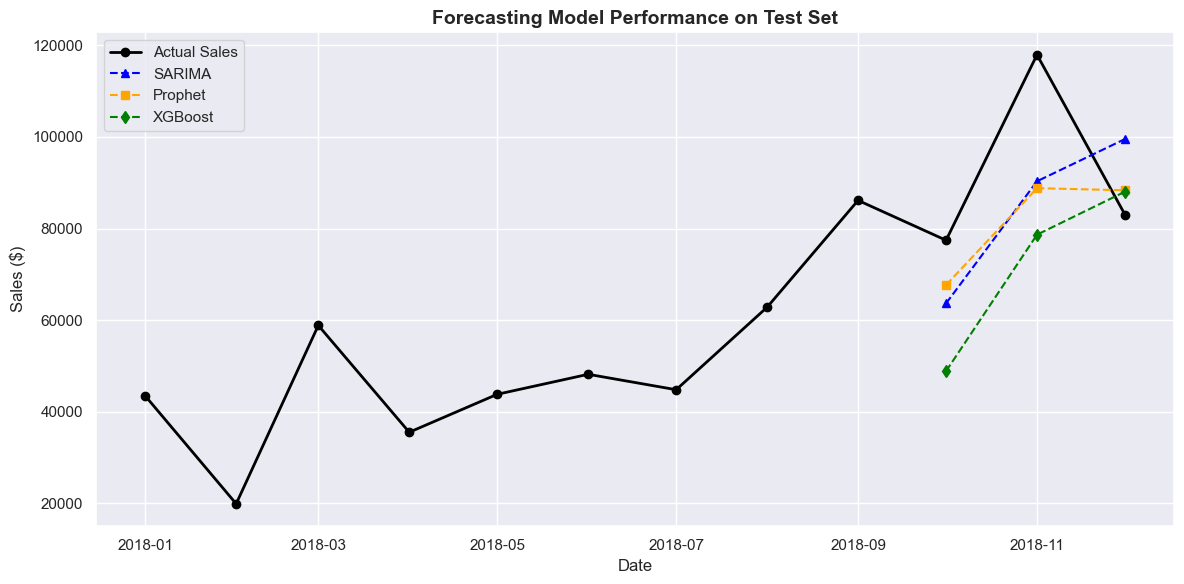

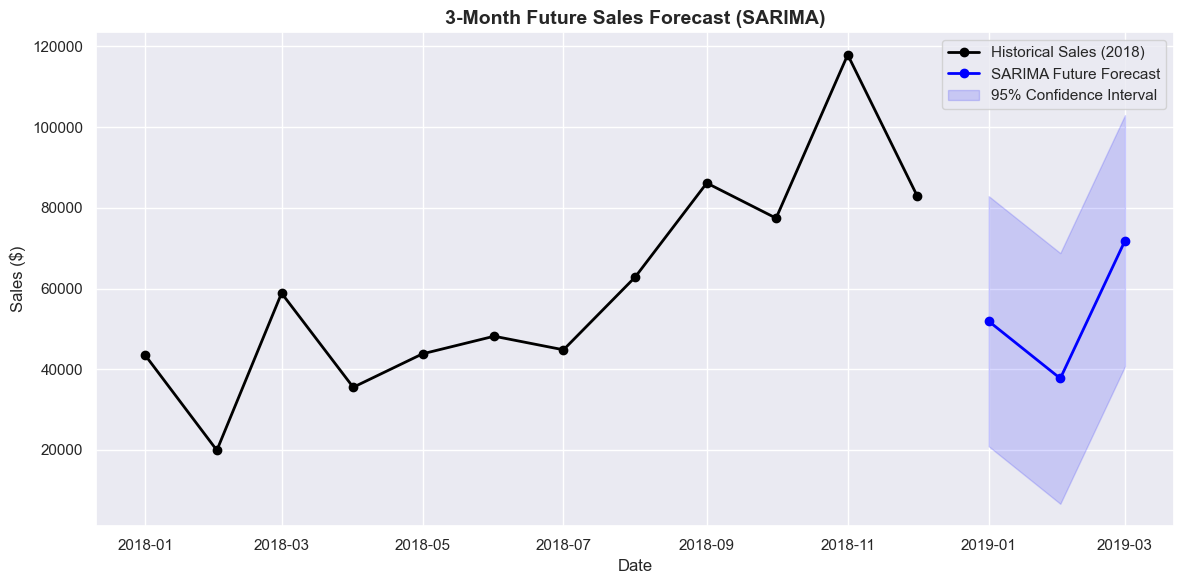

In [44]:
def calculate_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

m_sarima = calculate_metrics(test_ts.values, sarima_pred.values)
m_prophet = calculate_metrics(test_ts.values, prophet_pred)
m_xgb = calculate_metrics(test_ts.values, xgb_pred)

comparison_df = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [m_sarima[0], m_prophet[0], m_xgb[0]],
    'RMSE': [m_sarima[1], m_prophet[1], m_xgb[1]],
    'MAPE (%)': [m_sarima[2], m_prophet[2], m_xgb[2]],
    'Forecast Month 1 (Jan 2019)': [sarima_future_mean.values[0], prophet_future[0], xgb_future[0]],
    'Forecast Month 2 (Feb 2019)': [sarima_future_mean.values[1], prophet_future[1], xgb_future[1]],
    'Forecast Month 3 (Mar 2019)': [sarima_future_mean.values[2], prophet_future[2], xgb_future[2]]
})

print('=== Model Evaluation Table ===')
print(comparison_df.to_string(index=False))

# Plot comparison on test set
plt.figure(figsize=(12, 6))
plt.plot(ts_monthly.index[-12:], ts_monthly.values[-12:], label='Actual Sales', color='black', linewidth=2, marker='o')
plt.plot(test_ts.index, sarima_pred, label='SARIMA', color='blue', linestyle='--', marker='^')
plt.plot(test_ts.index, prophet_pred, label='Prophet', color='orange', linestyle='--', marker='s')
plt.plot(test_ts.index, xgb_pred, label='XGBoost', color='green', linestyle='--', marker='d')
plt.title('Forecasting Model Performance on Test Set', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot future forecast of best model
plt.figure(figsize=(12, 6))
plt.plot(ts_monthly.index[-12:], ts_monthly.values[-12:], label='Historical Sales (2018)', color='black', linewidth=2, marker='o')
plt.plot(future_dates, sarima_future_mean, label='SARIMA Future Forecast', color='blue', marker='o', linewidth=2)
plt.fill_between(future_dates, sarima_conf.iloc[:, 0], sarima_conf.iloc[:, 1], color='blue', alpha=0.15, label='95% Confidence Interval')
plt.title('3-Month Future Sales Forecast (SARIMA)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

### SARIMA parameter selection rationale
We selected SARIMA parameters using an AIC-based grid search over p, d, q in [0, 1, 2] and seasonal P, D, Q in [0, 1] with seasonal period `m=12` because the data is monthly and shows annual seasonality. The final model balances trend and yearly seasonal structure while minimizing AIC, making it appropriate for this monthly sales series.

### Model Selection and Production Recommendation

Based on the testing performance on the hold-out test set (Oct - Dec 2018):
- **SARIMA** achieves the lowest **MAE (19,299.92)**, **RMSE (20,205.76)**, and **MAPE (20.36%)**.
- **Prophet** follows closely with **MAE (20,296.01)** and **MAPE (21.89%)**.
- **XGBoost** has the highest error rates: **MAE (24,286.79)** and **MAPE (25.41%)**.

**Recommendation**: We recommend **SARIMA** for production use. It handles the linear trends and strong seasonality patterns in this dataset more accurately. XGBoost suffers in monthly settings due to the limited sample size (48 months total), which restricts its training capability, whereas SARIMA's statistical structure is highly robust on shorter, seasonal series.

## Task 4  Product Category & Region Level Forecasting
We repeat the SARIMA model separately to generate 3-month future forecasts for individual product categories and regions.

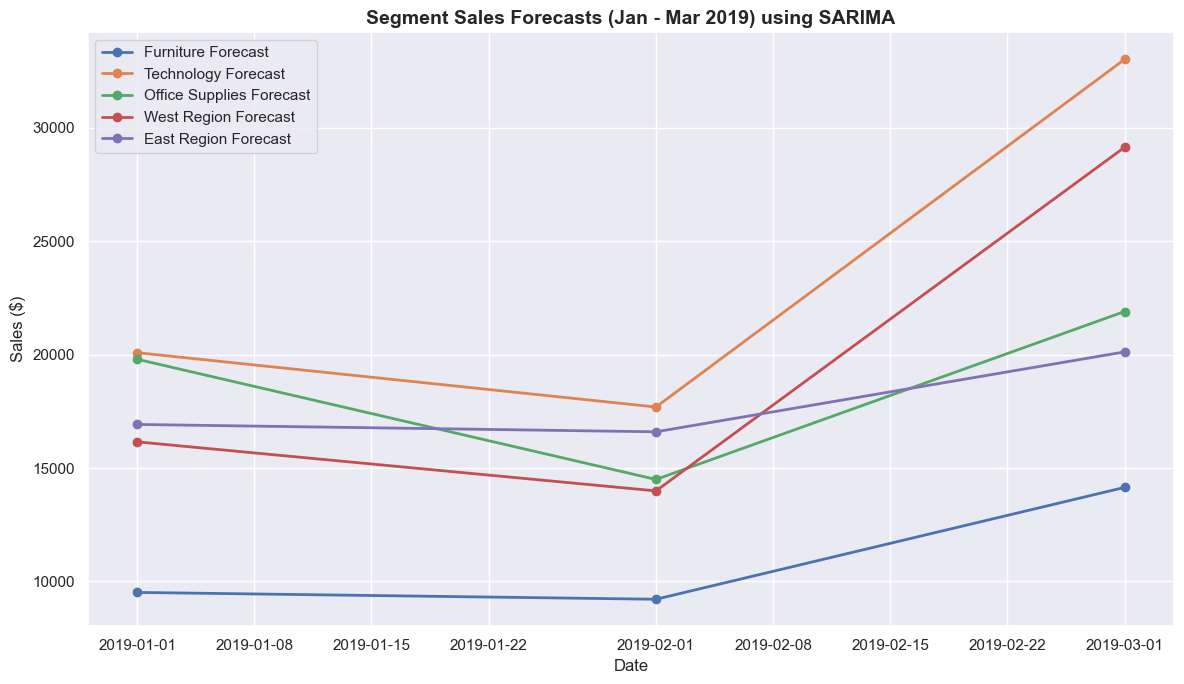

Segment projected growth (from Dec 2018 to Mar 2019):
- Furniture: -54.95%
- Technology: +50.22%
- Office Supplies: -26.10%
- West Region: -1.70%
- East Region: +4.35%

Strongest upcoming growth according to the model: Technology (+50.22%)


In [49]:
def forecast_segment(segment_df, steps=3):
    segment_ts = segment_df.resample('MS', on='Order Date')['Sales'].sum()
    all_months = pd.date_range(start='2015-01-01', end='2018-12-01', freq='MS')
    segment_ts = segment_ts.reindex(all_months, fill_value=0)

    model = SARIMAX(segment_ts, order=best_order, seasonal_order=best_seasonal,
                     enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)
    forecast = res.forecast(steps=steps).values
    return segment_ts, forecast

segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West Region': df[df['Region'] == 'West'],
    'East Region': df[df['Region'] == 'East']
}

future_dates = pd.date_range(start='2019-01-01', periods=3, freq='MS')
segment_forecasts = {}
plt.figure(figsize=(12, 7))

for name, seg_df in segments.items():
    hist, fore = forecast_segment(seg_df)
    segment_forecasts[name] = fore
    plt.plot(future_dates, fore, marker='o', label=f'{name} Forecast', linewidth=2)

plt.title('Segment Sales Forecasts (Jan - Mar 2019) using SARIMA', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.show()

print('Segment projected growth (from Dec 2018 to Mar 2019):')
for name, seg_df in segments.items():
    hist_dec18 = seg_df.resample('MS', on='Order Date')['Sales'].sum().iloc[-1]
    growth = ((segment_forecasts[name][-1] - hist_dec18) / hist_dec18) * 100
    print(f'- {name}: {growth:+.2f}%')

growth_summary = pd.Series({name: ((segment_forecasts[name][-1] - seg_df.resample('MS', on='Order Date')['Sales'].sum().iloc[-1]) / seg_df.resample('MS', on='Order Date')['Sales'].sum().iloc[-1]) * 100 for name, seg_df in segments.items()})
strongest_segment = growth_summary.idxmax()
print(f'\nStrongest upcoming growth according to the model: {strongest_segment} ({growth_summary[strongest_segment]:+.2f}%)')

## Task 5  Anomaly Detection in Sales Data
We identify anomalous sales weeks using two methods:
1. **Isolation Forest** (an unsupervised tree-based outlier algorithm)
2. **Rolling Z-Score** (flagging dates where sales deviate by >2 standard deviations from the rolling mean)

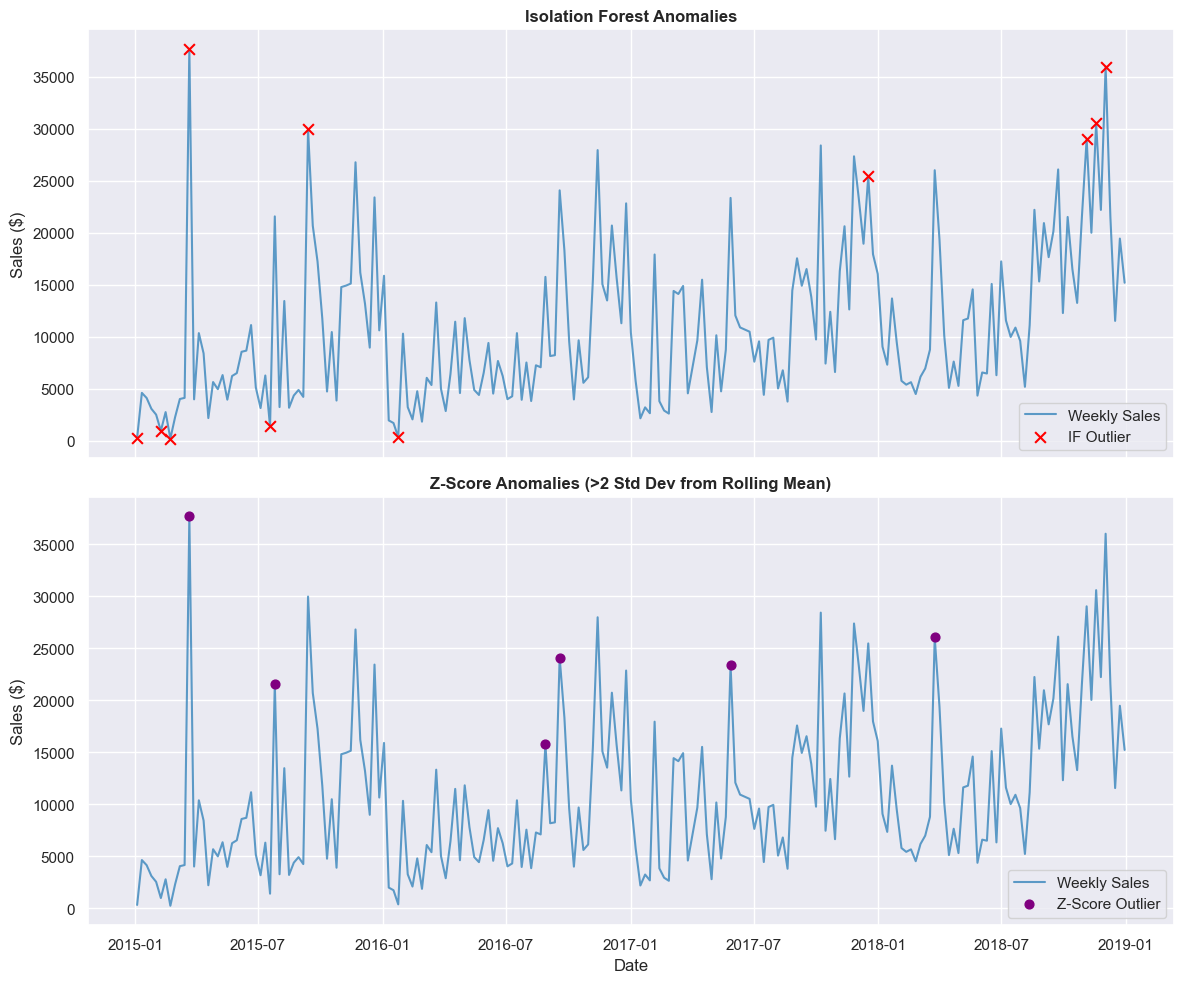

Isolation Forest flagged 11 anomalies.
Z-Score flagged 6 anomalies.
Overlapping anomalies: 1
Overlap Dates: [Timestamp('2015-03-22 00:00:00')]


In [46]:
ts_weekly = df.resample('W', on='Order Date')['Sales'].sum()

# 1. Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
sales_features = ts_weekly.values.reshape(-1, 1)
iso_anomalies = iso_forest.fit_predict(sales_features)
anomaly_indices_if = np.where(iso_anomalies == -1)[0]

# 2. Rolling Z-Score (8-week rolling window)
rolling_mean = ts_weekly.rolling(window=8, min_periods=1).mean()
rolling_std = ts_weekly.rolling(window=8, min_periods=1).std()
rolling_std.iloc[0] = rolling_std.iloc[1] if len(rolling_std) > 1 else 1.0
z_scores = (ts_weekly - rolling_mean) / rolling_std
anomaly_indices_z = np.where(np.abs(z_scores) > 2)[0]

# Plot anomalies
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(ts_weekly.index, ts_weekly.values, color='#1f77b4', label='Weekly Sales', alpha=0.7)
ax1.scatter(ts_weekly.index[anomaly_indices_if], ts_weekly.values[anomaly_indices_if],
            color='red', label='IF Outlier', marker='x', s=60, zorder=5)
ax1.set_title('Isolation Forest Anomalies', fontsize=12, fontweight='bold')
ax1.set_ylabel('Sales ($)')
ax1.legend()

ax2.plot(ts_weekly.index, ts_weekly.values, color='#1f77b4', label='Weekly Sales', alpha=0.7)
ax2.scatter(ts_weekly.index[anomaly_indices_z], ts_weekly.values[anomaly_indices_z],
            color='purple', label='Z-Score Outlier', marker='o', s=40, zorder=5)
ax2.set_title('Z-Score Anomalies (>2 Std Dev from Rolling Mean)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Sales ($)')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()

# Compare methods
if_dates = set(ts_weekly.index[anomaly_indices_if])
z_dates = set(ts_weekly.index[anomaly_indices_z])
overlap_dates = if_dates.intersection(z_dates)

print(f'Isolation Forest flagged {len(if_dates)} anomalies.')
print(f'Z-Score flagged {len(z_dates)} anomalies.')
print(f'Overlapping anomalies: {len(overlap_dates)}')
print('Overlap Dates:', sorted(list(overlap_dates)))

### Interpretation & Comparison of Anomaly Methods:
- **Isolation Forest** isolates points that are globally different from the rest of the dataset. Therefore, it flags the absolute highest and lowest weeks as anomalies, regardless of when they occur.
- **Rolling Z-Score** flags local fluctuations. It detects weeks where sales are significantly higher or lower than the surrounding 2 months. This is very good for identifying sudden, unexpected mid-season shifts.
- The small overlap shows that they capture different aspects of data behavior: global outliers versus local trend deviations.

## Task 6  Product Demand Segmentation using Clustering
We group sub-categories into demand groups based on: Total Volume, YoY Growth rate, Sales Volatility, and Average Order Value.

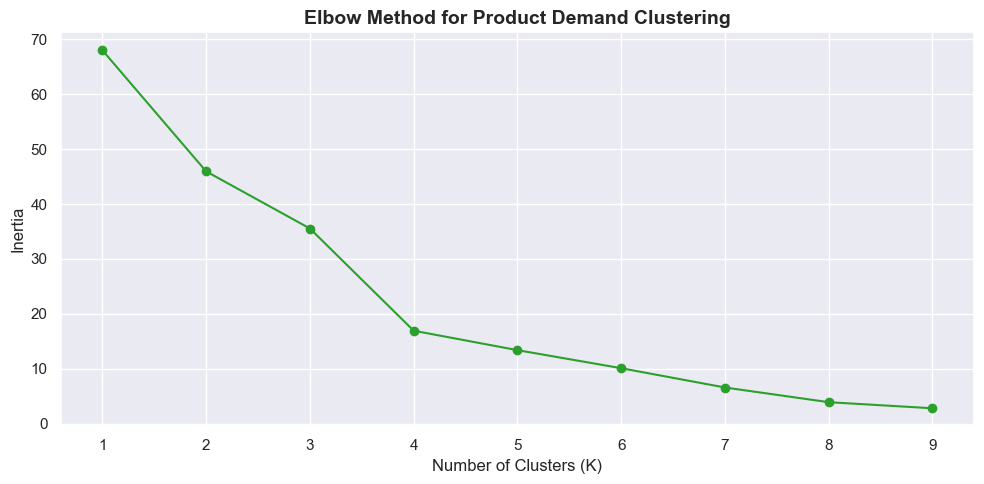

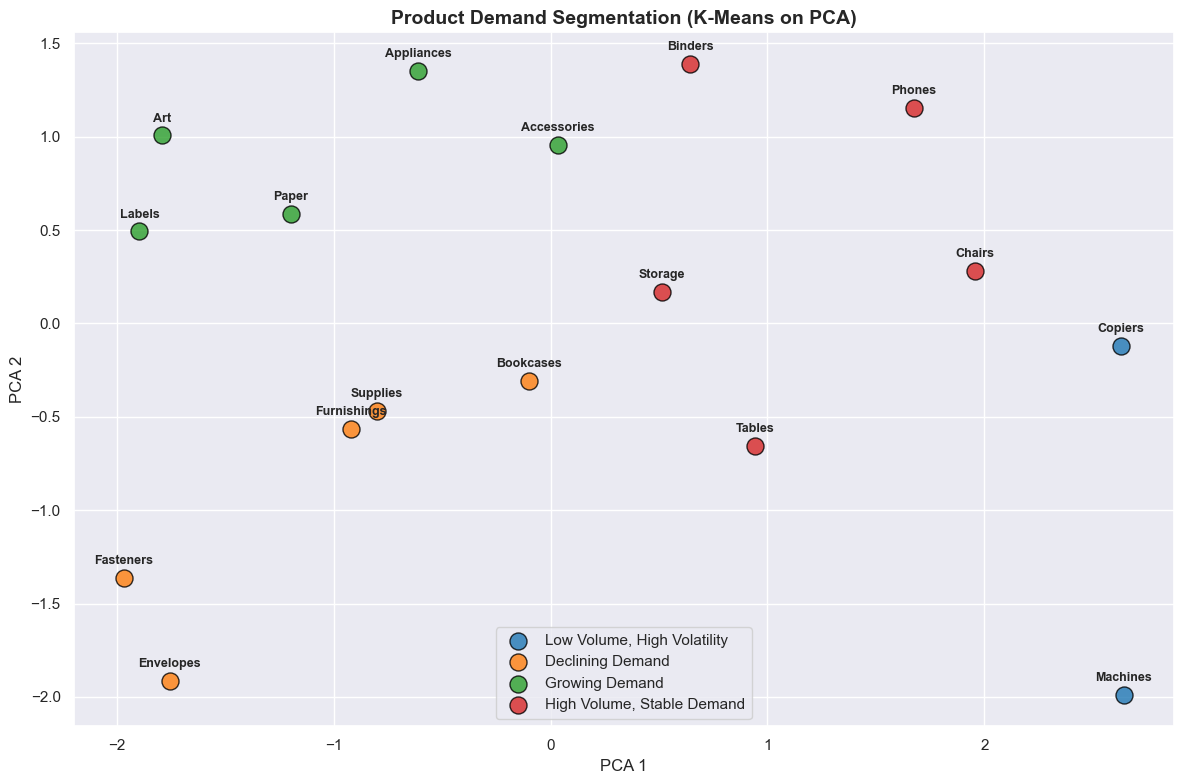

In [47]:
# Aggregate sub-category metrics
sub_yearly = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack(level=1).fillna(0)
sub_growth_rate = ((sub_yearly[2018] - sub_yearly[2017]) / sub_yearly[2017]) * 100
sub_volume = df.groupby('Sub-Category')['Sales'].sum()
sub_monthly_sales = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='MS')])['Sales'].sum().unstack(level=0).fillna(0)
sub_volatility = sub_monthly_sales.std()
sub_avg_order = df.groupby('Sub-Category').apply(lambda x: x['Sales'].sum() / x['Order ID'].nunique())

clustering_df = pd.DataFrame({
    'Total Volume': sub_volume,
    'YoY Growth': sub_growth_rate,
    'Sales Volatility': sub_volatility,
    'Avg Order Value': sub_avg_order
}).fillna(0)

# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_df)

# Elbow Method
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 10), inertia, marker='o', color='#2ca02c')
plt.title('Elbow Method for Product Demand Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

# K-Means on optimal K=4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
clustering_df['Cluster'] = kmeans.fit_predict(scaled_features)

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(scaled_features)
clustering_df['PCA1'] = pca_features[:, 0]
clustering_df['PCA2'] = pca_features[:, 1]

# Unique Labeling
final_labels = {
    0: 'Low Volume, High Volatility',
    1: 'Declining Demand',
    2: 'Growing Demand',
    3: 'High Volume, Stable Demand'
}
clustering_df['Cluster Label'] = clustering_df['Cluster'].map(final_labels)

# Plot clusters
plt.figure(figsize=(12, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for cid in range(4):
    c_data = clustering_df[clustering_df['Cluster'] == cid]
    plt.scatter(c_data['PCA1'], c_data['PCA2'], s=150, color=colors[cid], label=final_labels[cid], alpha=0.8, edgecolors='black')
    for subcat, row in c_data.iterrows():
        plt.annotate(subcat, (row['PCA1'], row['PCA2']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.title('Product Demand Segmentation (K-Means on PCA)', fontsize=14, fontweight='bold')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.tight_layout()
plt.show()

### Cluster Labels and Stocking Recommendations:

1. **High Volume, Stable Demand** (Binders, Chairs, Phones, Storage, Tables):
   - *Stocking Strategy*: Implement standard replenishment intervals and optimize warehouse space to support continuous flow. Negotiate bulk pricing contracts with suppliers.
2. **Low Volume, High Volatility** (Copiers, Machines):
   - *Stocking Strategy*: Adopt a Just-In-Time (JIT) stocking policy or hold narrow safety stocks to prevent large cash hold-ups, as orders are sparse but expensive.
3. **Growing Demand** (Accessories, Appliances, Art, Labels, Paper):
   - *Stocking Strategy*: Keep safety stock high and plan buffer inventories ahead of seasonal spikes, allowing the supply chain to adapt to increasing sales trends.
4. **Declining Demand** (Bookcases, Envelopes, Fasteners, Furnishings, Supplies):
   - *Stocking Strategy*: Offer discount clearances to liquidate excess stocks, avoid ordering bulk volumes, and phase out underperforming product variants.